<a href="https://colab.research.google.com/github/Saddin13/AulaIA/blob/main/AI6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

In [2]:
import pandas as pd

df = pd.read_csv("precos-gasolina-etanol-12.csv", sep=';')

#converter virgula para ponto
df["Valor de Venda"] = df["Valor de Venda"].str.replace(",", ".").astype(float)
#Data padrao Ingles
df["Data da Coleta"] = pd.to_datetime(df["Data da Coleta"], dayfirst=True)

df.head(15)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,RODOVIA AL-220,5848,KM 96,BOM SUCESSO,57309-035,GASOLINA,2025-12-01,6.14,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,RODOVIA AL-220,5848,KM 96,BOM SUCESSO,57309-035,GASOLINA ADITIVADA,2025-12-01,6.14,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,RODOVIA AL-220,5848,KM 96,BOM SUCESSO,57309-035,ETANOL,2025-12-01,4.79,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,AUTO POSTO MASSARANDUBA LTDA,07.248.398/0001-29,RODOVIA AL 220,4698,NaN,PLANALTO,57308-000,GASOLINA,2025-12-01,6.19,NaN,R$ / litro,BRANCA
4,NE,AL,ARAPIRACA,AUTO POSTO MASSARANDUBA LTDA,07.248.398/0001-29,RODOVIA AL 220,4698,NaN,PLANALTO,57308-000,GASOLINA ADITIVADA,2025-12-01,6.19,NaN,R$ / litro,BRANCA
5,NE,AL,ARAPIRACA,AUTO POSTO MASSARANDUBA LTDA,07.248.398/0001-29,RODOVIA AL 220,4698,NaN,PLANALTO,57308-000,ETANOL,2025-12-01,4.89,NaN,R$ / litro,BRANCA
6,NE,AL,ARAPIRACA,POSTO ATLANTIC CONFIANCA LTDA,08.461.170/0001-85,RUA QUINZE DE NOVEMBRO,470,NaN,CENTRO,57300-340,GASOLINA,2025-12-01,6.09,NaN,R$ / litro,IPIRANGA
7,NE,AL,ARAPIRACA,POSTO E HOTEL DI'VAN LTDA,24.313.645/0001-42,AVENIDA ANTONIO SERMEAO L FILHO,406,NaN,JARDIM TROPICAL,57304-820,GASOLINA,2025-12-01,6.19,NaN,R$ / litro,VIBRA
8,NE,AL,ARAPIRACA,DISTRIBUIDORA DE VEICULOS CONFIANCA LIMITADA,12.396.339/0001-38,RUA QUINZE DE NOVEMBRO,451,NaN,BRASILIA,57313-015,GASOLINA,2025-12-01,6.09,NaN,R$ / litro,RAIZEN
9,NE,AL,ARAPIRACA,DISTRIBUIDORA DE VEICULOS CONFIANCA LIMITADA,12.396.339/0001-38,RUA QUINZE DE NOVEMBRO,451,NaN,BRASILIA,57313-015,GASOLINA ADITIVADA,2025-12-01,6.49,NaN,R$ / litro,RAIZEN


In [ ]:
df.describe()

,Data da Coleta,Valor de Venda,Valor de Compra
count,52336,52336.000000,0.0
mean,2025-12-15 14:40:57.597065216,5.728101,NaN
min,2025-12-01 00:00:00,3.490000,NaN
25%,2025-12-08 00:00:00,4.790000,NaN
50%,2025-12-16 00:00:00,5.990000,NaN
75%,2025-12-23 00:00:00,6.390000,NaN
max,2025-12-31 00:00:00,9.590000,NaN
std,NaN,0.908264,NaN


In [ ]:
df_produto = df.groupby(["Produto","Estado - Sigla"])["Valor de Venda"]
df_produto.describe()

count      mean       std   min     25%  \
Produto            Estado - Sigla                                             
ETANOL             AC                33.0  5.373939  0.307276  5.09  5.1900   
                   AL               206.0  4.972282  0.176188  4.39  4.8900   
                   AM               181.0  5.475801  0.046631  5.39  5.4800   
                   AP                 4.0  5.727500  0.125000  5.54  5.7275   
                   BA               892.0  4.774249  0.346492  3.99  4.5500   
...                                   ...       ...       ...   ...     ...   
GASOLINA ADITIVADA RS              1500.0  6.420920  0.284580  5.75  6.2500   
                   SC               652.0  6.415629  0.193108  5.69  6.2900   
                   SE               138.0  6.546087  0.161451  6.32  6.4100   
                   SP              4417.0  6.355003  0.424023  5.24  6.0900   
                   TO                86.0  6.633372  0.185869  5.99  6.4900   

                                    50%   75%   max  
Produto            Estado - Sigla                    
ETANOL             AC              5.25  5.29  6.08  
                   AL              4.99  5.11  5.31  
                   AM              5.49  5.49  5.59  
                   AP              5.79  5.79  5.79  
                   BA              4.73  4.99  5.99  
...                                 ...   ...   ...  
GASOLINA ADITIVADA RS              6.39  6.59  7.54  
                   SC              6.40  6.54  6.89  
                   SE              6.57  6.66  6.91  
                   SP              6.29  6.59  9.59  
                   TO              6.64  6.69  6.99  

[81 rows x 8 columns]

In [3]:
df_produto = df.groupby("Estado - Sigla")["Valor de Venda"]
df_produto.describe()

,count,mean,std,min,25%,50%,75%,max
Estado - Sigla,,,,,,,,
AC,111.0,6.836306,1.011790,5.09,5.950,7.33,7.39,8.17
AL,643.0,5.953484,0.737807,4.39,5.120,6.23,6.39,7.28
AM,688.0,6.723808,0.850912,5.39,5.590,6.99,6.99,8.39
AP,56.0,6.077679,0.174700,5.54,5.940,6.07,6.12,6.46
BA,2580.0,5.824388,0.828730,3.99,4.960,6.15,6.49,7.20
CE,1632.0,5.794718,0.725912,4.20,5.190,6.09,6.38,6.75
DF,571.0,6.078687,0.657168,4.19,6.230,6.37,6.45,6.89
ES,1046.0,5.890918,0.829392,4.15,4.990,6.29,6.44,7.09
GO,2018.0,5.825173,0.835992,3.94,4.970,6.29,6.49,7.27


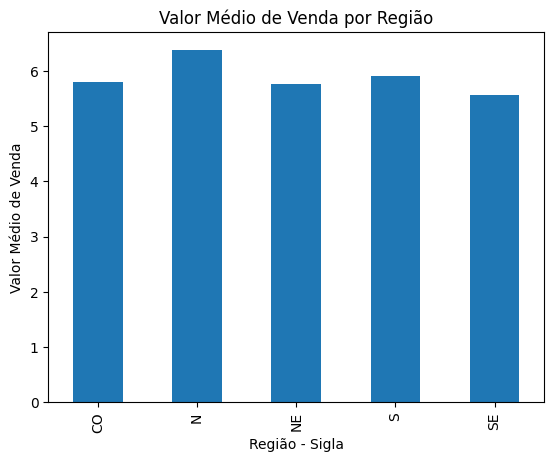

In [8]:
import matplotlib.pyplot as plt

media_regiao = df.groupby("Regiao - Sigla")["Valor de Venda"].mean()
ax = media_regiao.plot(kind="bar")
ax.set_xlabel("Região - Sigla") # Changing the x-axis label
ax.set_ylabel("Valor Médio de Venda") # Setting a y-axis label for clarity
ax.set_title("Valor Médio de Venda por Região") # Setting a title
plt.show()

In [12]:
df_modelo = df[["Regiao - Sigla","Estado - Sigla","Produto","Bandeira", "Valor de Venda"]]
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52336 entries, 0 to 52335
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Regiao - Sigla  52336 non-null  object 
 1   Estado - Sigla  52336 non-null  object 
 2   Produto         52336 non-null  object 
 3   Bandeira        52336 non-null  object 
 4   Valor de Venda  52336 non-null  float64
dtypes: float64(1), object(4)
memory usage: 2.0+ MB


In [20]:
df_modelodummie = pd.get_dummies(df_modelo, drop_first=True)

In [21]:
x = df_modelodummie.drop("Valor de Venda", axis=1)
y = df_modelodummie["Valor de Venda"]

df_modelodummie.head()

,Valor de Venda,Regiao - Sigla_N,Regiao - Sigla_NE,Regiao - Sigla_S,Regiao - Sigla_SE,Estado - Sigla_AL,Estado - Sigla_AM,Estado - Sigla_AP,Estado - Sigla_BA,Estado - Sigla_CE,...,Bandeira_SETTA DISTRIBUIDORA,Bandeira_SIM DISTRIBUIDOR,Bandeira_SP,Bandeira_STANG,Bandeira_TAURUS,Bandeira_TDC DISTRIBUIDORA,Bandeira_TEMAPE,Bandeira_VIBRA,Bandeira_WALENDOWSKY,Bandeira_WATT
0,6.14,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,6.14,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,4.79,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,6.19,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,6.19,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
x = df_modelodummie.drop("Valor de Venda", axis=1)
y = df_modelodummie["Valor de Venda"]

In [19]:
from sklearn.model_selection import train_test_split

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y)

In [24]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(x_train, y_train)

LinearRegression()

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

pred = modelo.predict(x_test)

mse = mean_squared_error(y_test, pred)

print("MSE: ", mse)
print("R2", r2_score(y_test, pred))

MSE:  0.09887407710277385
R2 0.880328391092488
